---
numbering: false
---

# 2.3: Orthogonal projections

In [1]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import sys

_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
if str(_notes_root) not in sys.path:
    sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly

BLUE, ORANGE, PINK = '#3d81f6', 'orange', '#d81a60'


def base2(xrange=(-5, 6), yrange=(-5, 5), width=700, height=580, tick=1):
    fig = style_plotly(go.Figure(), renderer='png')
    fig.update_layout(width=width, height=height, showlegend=False,
                      font=dict(size=17), margin=dict(l=55, r=30, t=30, b=50))
    fig.update_xaxes(title='x', range=xrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain', scaleanchor='y', scaleratio=1)
    fig.update_yaxes(title='y', range=yrange, dtick=tick, zeroline=True, zerolinewidth=1.5,
                     constrain='domain')
    return fig


def line2(fig, start, end, color=BLUE, dash='solid', width=2):
    fig.add_trace(go.Scatter(x=[start[0], end[0]], y=[start[1], end[1]], mode='lines',
                            line=dict(color=color, width=width, dash=dash),
                            hoverinfo='skip', showlegend=False))


def label2(fig, xy, label, dx=0, dy=0):
    fig.add_annotation(x=float(xy[0])+dx, y=float(xy[1])+dy, text=label, showarrow=False,
                       font=dict(color='black', size=17))


def point2(fig, xy, label=None, dx=0.35, dy=0.35):
    fig.add_trace(go.Scatter(x=[xy[0]], y=[xy[1]], mode='markers',
                            marker=dict(color='black', size=7), hoverinfo='skip'))
    if label: label2(fig, xy, label, dx, dy)


def vec2(fig, end, label=None, color=BLUE, start=(0, 0), dx=0.25, dy=0.3, width=3):
    fig.add_annotation(x=float(end[0]), y=float(end[1]), ax=float(start[0]), ay=float(start[1]),
                       xref='x', yref='y', axref='x', ayref='y', showarrow=True,
                       text='', arrowhead=3, arrowsize=1.25, arrowwidth=width, arrowcolor=color)
    if label: label2(fig,end,label,dx,dy)


def square2(fig, corner, along, perp, size=0.3):
    corner=np.asarray(corner,dtype=float)
    u=np.asarray(along,dtype=float); u=u/np.linalg.norm(u)*size
    v=np.asarray(perp,dtype=float); v=v/np.linalg.norm(v)*size
    line2(fig,corner+u,corner+u+v,'gray',width=1.5)
    line2(fig,corner+v,corner+u+v,'gray',width=1.5)


def base3():
    fig=style_plotly(go.Figure(),renderer='plotly_mimetype')
    axis=dict(range=[-6,7],dtick=2,showbackground=True,showspikes=False)
    fig.update_layout(width=760,height=620,showlegend=False,font=dict(size=16),
                      margin=dict(l=0,r=0,t=15,b=0),
                      scene=dict(xaxis=dict(title='x',**axis),yaxis=dict(title='y',**axis),
                                 zaxis=dict(title='z',**axis),aspectmode='cube',
                                 camera=dict(eye=dict(x=1.6,y=-2.1,z=1.3))))
    for direction in np.eye(3):
        line3(fig,-6*direction,7*direction,'#9ca3af',width=2)
    return fig


def line3(fig,start,end,color=BLUE,width=5,dash='solid'):
    fig.add_trace(go.Scatter3d(x=[start[0],end[0]],y=[start[1],end[1]],z=[start[2],end[2]],
                              mode='lines',line=dict(color=color,width=width,dash=dash),
                              hoverinfo='skip',showlegend=False))


def vec3(fig,end,label,color=BLUE,start=(0,0,0),offset=(0.25,0.25,0.35)):
    start,end=np.asarray(start,float),np.asarray(end,float)
    direction=(end-start)/np.linalg.norm(end-start)
    line3(fig,start,end-0.15*direction,color,width=7)
    fig.add_trace(go.Cone(x=[end[0]],y=[end[1]],z=[end[2]],u=[direction[0]],v=[direction[1]],w=[direction[2]],
                         anchor='tip',sizemode='absolute',sizeref=0.45,colorscale=[[0,color],[1,color]],
                         showscale=False,hoverinfo='skip'))
    pos=end+offset
    fig.add_trace(go.Scatter3d(x=[pos[0]],y=[pos[1]],z=[pos[2]],mode='text',text=[label],
                              textfont=dict(color='black',size=16),hoverinfo='skip'))


def plane3(fig,normal,color=BLUE,opacity=0.24):
    # Solve n_x*x + n_y*y + n_z*z = 0 for y on a rectangular x,z mesh.
    x,z=np.meshgrid(np.linspace(-5,6,2),np.linspace(-5,6,2))
    n=np.asarray(normal,float)
    y=-(n[0]*x+n[2]*z)/n[1]
    fig.add_trace(go.Surface(x=x.tolist(),y=y.tolist(),z=z.tolist(),
                            colorscale=[[0,color],[1,color]],opacity=opacity,
                            showscale=False,hoverinfo='skip'))
    corners=np.array([[x[0,0],y[0,0],z[0,0]],[x[0,1],y[0,1],z[0,1]],
                      [x[1,1],y[1,1],z[1,1]],[x[1,0],y[1,0],z[1,0]]])
    for i in range(4): line3(fig,corners[i],corners[(i+1)%4],color,width=2)


In [Chapter 2.2](02-02.ipynb), we used an orthonormal basis to split a vector into two perpendicular parts. Now we'll focus on just one of those parts: the component along a given line. This is called an **orthogonal projection**.

## Decomposing a vector into perpendicular components

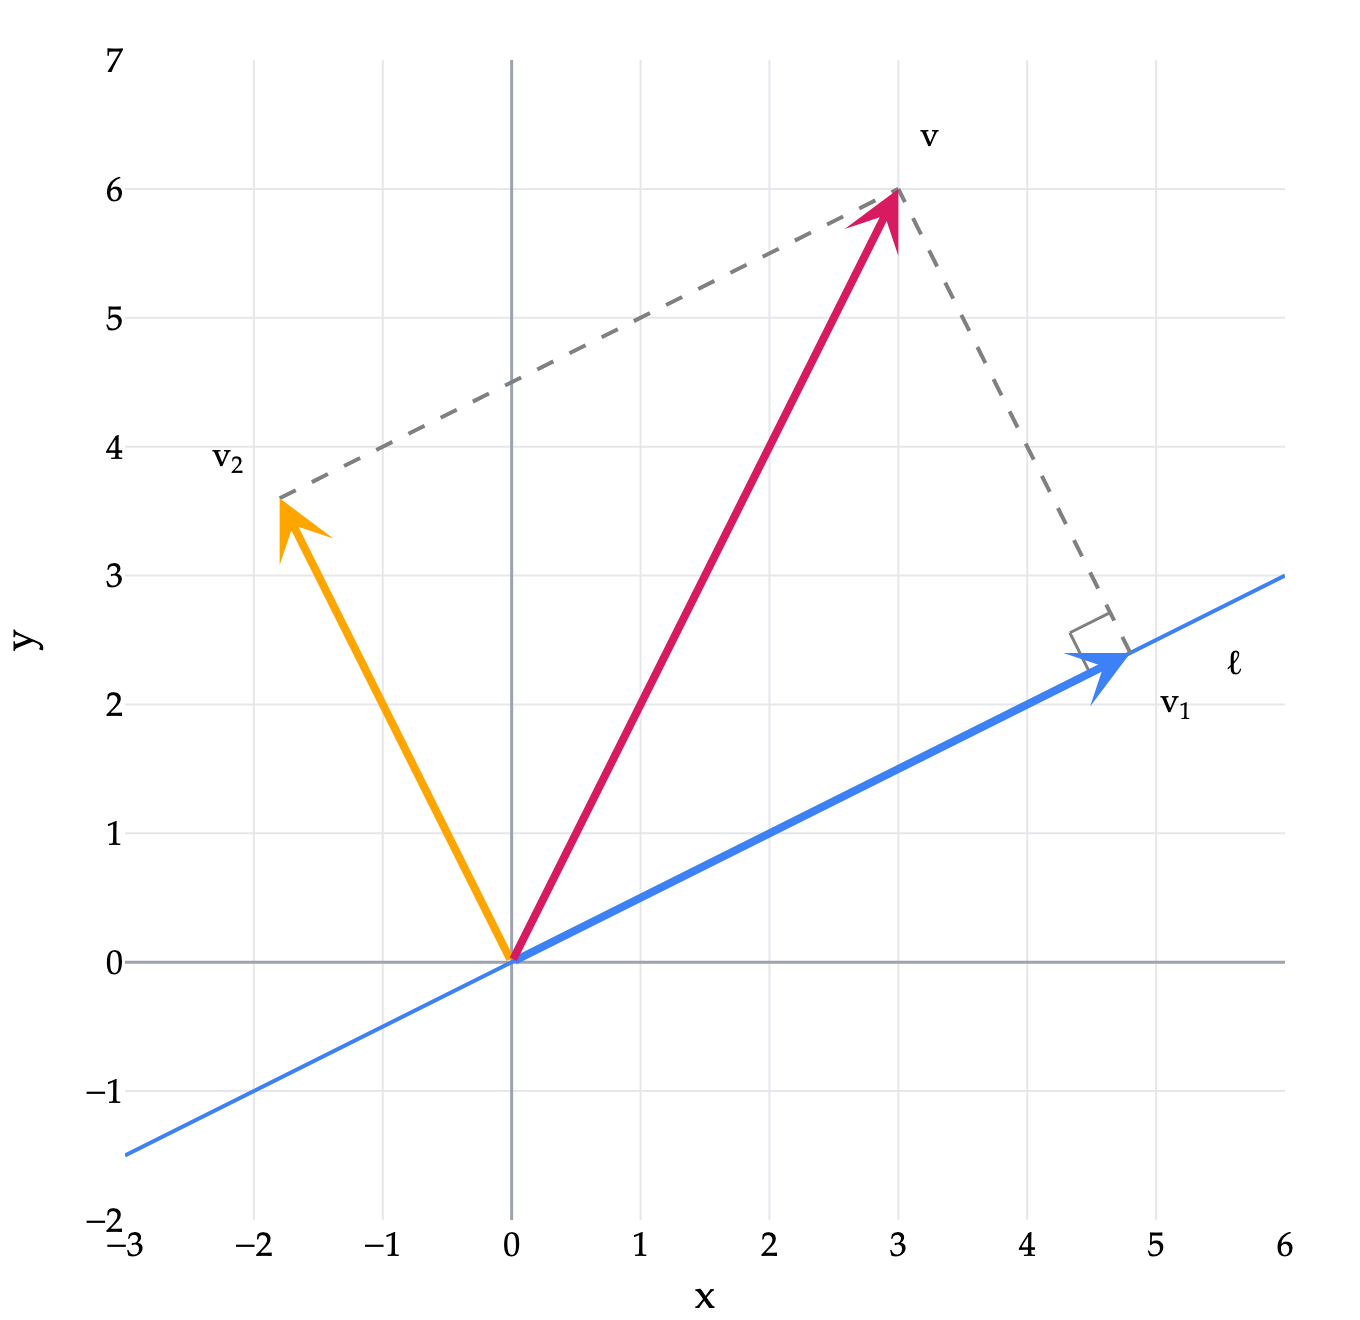

In [2]:
fig=base2((-3,6),(-2,7),width=680,height=660)
w=np.array([2,1]); v=np.array([3,6]); p=(v@w)/(w@w)*w; q=v-p
line2(fig,(-3,-1.5),(6,3),BLUE)
line2(fig,p,v,'gray','dash'); line2(fig,q,v,'gray','dash')
vec2(fig,p,'v<sub>1</sub>',BLUE,dx=0.35,dy=-0.4,width=4)
vec2(fig,q,'v<sub>2</sub>',ORANGE,dx=-0.4,dy=0.3,width=4)
vec2(fig,v,'v',PINK,dx=0.25,dy=0.4,width=4)
square2(fig,p,-w,q,0.35)
label2(fig,(5.6,2.3),'ℓ')
fig.show(scale=2)

A vector can be resolved into a part along a line and a part perpendicular to the line.

Now suppose $\vec v$ is some vector in $\mathbb{R}^2$, and $\ell$ is a line in
$\mathbb{R}^2$ going through the origin.

We can write $\vec v$ as the sum of two vectors, one along $\ell$, and one
perpendicular to $\ell$:

$$
\vec v=\vec v_1+\vec v_2.
$$

The vector $\vec v_1$ is called the orthogonal projection of $\vec v$ to
$\ell$.

## Finding the projection onto a line

How do we find it?

First, we can pick a unit vector $\vec u_1$ along $\ell$, and a unit vector
$\vec u_2$ perpendicular to $\ell$.

Then $(\vec u_1,\vec u_2)$ is an orthonormal basis of $\mathbb{R}^2$.

In [Chapter 2.2](02-02.ipynb), we saw that

$$
\vec v
=
(\vec v\cdot \vec u_1)\vec u_1
+
(\vec v\cdot \vec u_2)\vec u_2.
$$

The first term is along $\ell$, and the second term is perpendicular to $\ell$.
Therefore

:::{note} Orthogonal projection onto a line

For a unit vector $\vec u_1$ along $\ell$,

$$
\operatorname{proj}_{\ell}(\vec v)
=
\vec v_1
=
(\vec v\cdot \vec u_1)\vec u_1.
$$

:::

## Worked example

Find the orthogonal projection of the vector

$$
\begin{bmatrix}
8\\
9
\end{bmatrix}
$$

to the line

$$
2x-3y=0.
$$

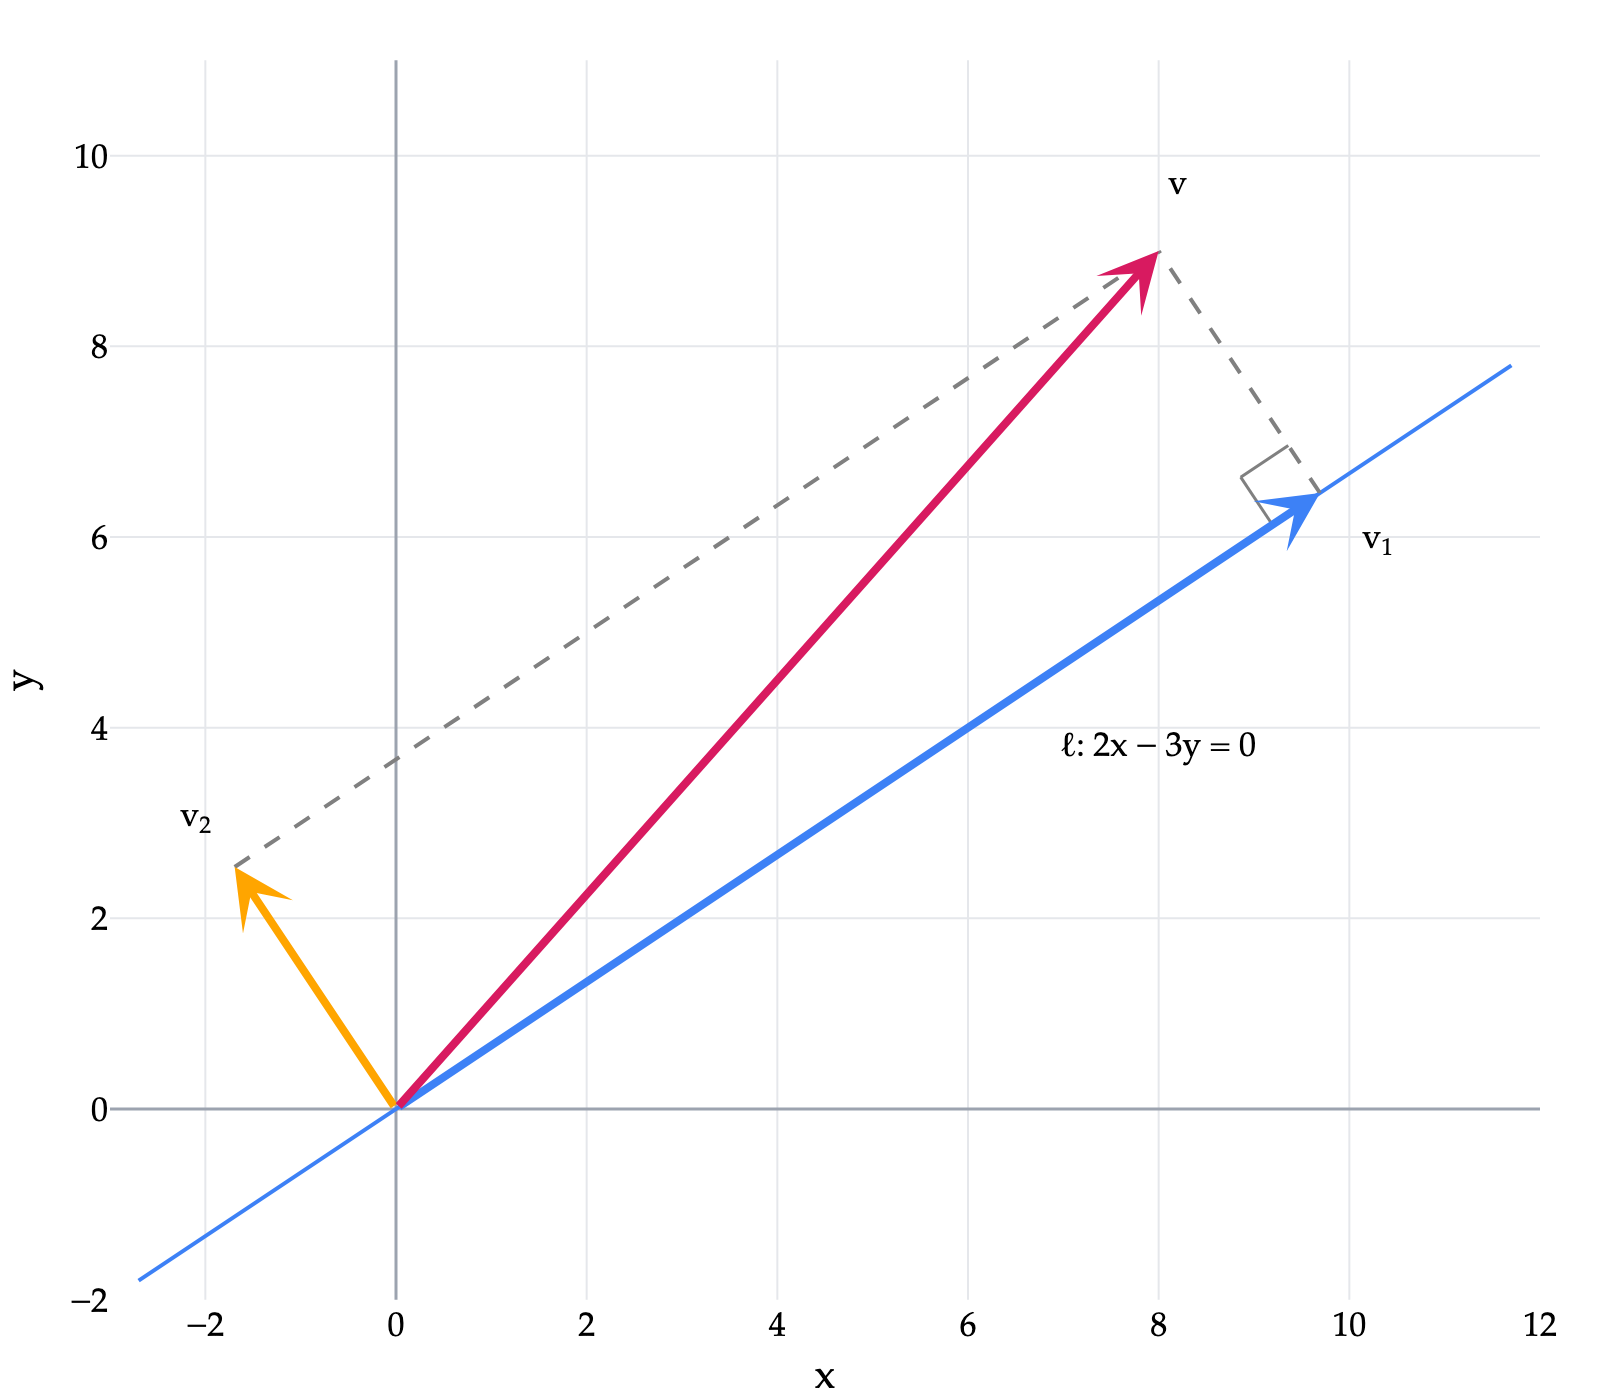

In [3]:
fig=base2((-3,12),(-2,11),width=800,height=700,tick=2)
v=np.array([8,9]); w=np.array([3,2]); p=(v@w)/(w@w)*w; q=v-p
line2(fig,(-2.7,-1.8),(11.7,7.8),BLUE)
line2(fig,p,v,'gray','dash'); line2(fig,q,v,'gray','dash')
vec2(fig,p,'v<sub>1</sub>',BLUE,dx=0.6,dy=-0.5,width=4)
vec2(fig,q,'v<sub>2</sub>',ORANGE,dx=-0.4,dy=0.5,width=4)
vec2(fig,v,'v',PINK,dx=0.2,dy=0.7,width=4)
square2(fig,p,-w,q,0.6)
label2(fig,(8,3.8),'ℓ: 2x − 3y = 0')
fig.show(scale=2)

Projection of $\vec v=\begin{bmatrix}8\\9\end{bmatrix}$ onto the line $2x-3y=0$.

A vector along the line $2x-3y=0$ is

$$
\begin{bmatrix}
3\\
2
\end{bmatrix}
=
\vec w.
$$

Its length is

$$
\lVert \vec w\rVert
=
\sqrt{9+4}
=
\sqrt{13}.
$$

Following the normalization procedure from [Chapter 1.5](../ch01/01-05.ipynb), divide $\vec w$ by $\sqrt{13}$. A unit vector along $\ell$ is

$$
\vec u_1
=
\begin{bmatrix}
\frac{3}{\sqrt{13}}\\[2pt]
\frac{2}{\sqrt{13}}
\end{bmatrix}.
$$

So the projection is

$$
\operatorname{proj}_{\ell}(\vec v)
=
(\vec v\cdot \vec u_1)\vec u_1.
$$

Thus

$$
\operatorname{proj}_{\ell}(\vec v)
=
\left(
\begin{bmatrix}
8\\
9
\end{bmatrix}
\cdot
\begin{bmatrix}
\frac{3}{\sqrt{13}}\\[2pt]
\frac{2}{\sqrt{13}}
\end{bmatrix}
\right)
\begin{bmatrix}
\frac{3}{\sqrt{13}}\\[2pt]
\frac{2}{\sqrt{13}}
\end{bmatrix}.
$$

Since

$$
\begin{bmatrix}
8\\
9
\end{bmatrix}
\cdot
\begin{bmatrix}
\frac{3}{\sqrt{13}}\\[2pt]
\frac{2}{\sqrt{13}}
\end{bmatrix}
=
\frac{24}{\sqrt{13}}+\frac{18}{\sqrt{13}}
=
\frac{42}{\sqrt{13}},
$$

we get

$$
\operatorname{proj}_{\ell}(\vec v)
=
\frac{42}{\sqrt{13}}
\begin{bmatrix}
\frac{3}{\sqrt{13}}\\[2pt]
\frac{2}{\sqrt{13}}
\end{bmatrix}
=
\begin{bmatrix}
\frac{126}{13}\\[2pt]
\frac{84}{13}
\end{bmatrix}.
$$

## Projection onto the perpendicular line

Likewise, we can find the projection to $\ell^\perp$.

Since

$$
\vec u_1
=
\begin{bmatrix}
\frac{3}{\sqrt{13}}\\[2pt]
\frac{2}{\sqrt{13}}
\end{bmatrix},
$$

we can take

$$
\vec u_2
=
\begin{bmatrix}
-\frac{2}{\sqrt{13}}\\[2pt]
\frac{3}{\sqrt{13}}
\end{bmatrix}.
$$

Then

$$
\operatorname{proj}_{\ell^\perp}(\vec v)
=
(\vec v\cdot \vec u_2)\vec u_2.
$$

So

$$
\operatorname{proj}_{\ell^\perp}(\vec v)
=
\left(
\begin{bmatrix}
8\\
9
\end{bmatrix}
\cdot
\begin{bmatrix}
-\frac{2}{\sqrt{13}}\\[2pt]
\frac{3}{\sqrt{13}}
\end{bmatrix}
\right)
\begin{bmatrix}
-\frac{2}{\sqrt{13}}\\[2pt]
\frac{3}{\sqrt{13}}
\end{bmatrix}.
$$

Since

$$
\begin{bmatrix}
8\\
9
\end{bmatrix}
\cdot
\begin{bmatrix}
-\frac{2}{\sqrt{13}}\\[2pt]
\frac{3}{\sqrt{13}}
\end{bmatrix}
=
-\frac{16}{\sqrt{13}}+\frac{27}{\sqrt{13}}
=
\frac{11}{\sqrt{13}},
$$

we get

$$
\operatorname{proj}_{\ell^\perp}(\vec v)
=
\frac{11}{\sqrt{13}}
\begin{bmatrix}
-\frac{2}{\sqrt{13}}\\[2pt]
\frac{3}{\sqrt{13}}
\end{bmatrix}
=
\begin{bmatrix}
-\frac{22}{13}\\[2pt]
\frac{33}{13}
\end{bmatrix}.
$$

Then

$$
\vec v
=
\vec v_1+\vec v_2,
$$

where

$$
\vec v_1=
\begin{bmatrix}
\frac{126}{13}\\[2pt]
\frac{84}{13}
\end{bmatrix},
\qquad
\vec v_2=
\begin{bmatrix}
-\frac{22}{13}\\[2pt]
\frac{33}{13}
\end{bmatrix}.
$$

Check:

$$
\begin{bmatrix}
\frac{126}{13}\\[2pt]
\frac{84}{13}
\end{bmatrix}
+
\begin{bmatrix}
-\frac{22}{13}\\[2pt]
\frac{33}{13}
\end{bmatrix}
=
\begin{bmatrix}
\frac{104}{13}\\[2pt]
\frac{117}{13}
\end{bmatrix}
=
\begin{bmatrix}
8\\
9
\end{bmatrix}.
$$

We have resolved one vector $\vec v$ into two orthogonal directions,
with $\vec v_1$ along $\ell$ and $\vec v_2$ along $\ell^\perp$.

There is also a quick way to find the perpendicular component once we know the projection:

$$
\operatorname{proj}_{\ell^\perp}(\vec v)=\vec v-\operatorname{proj}_{\ell}(\vec v).
$$

This is the vector subtraction from [Chapter 1.4](../ch01/01-04.ipynb). As a check, the two components have dot product zero, so they are orthogonal as in [Chapter 1.6](../ch01/01-06.ipynb).